# Analisis Spatial Scale — Menggunakan Kelas `Scale` Asli

Notebook ini menguji augmentasi **Spatial Scale** dengan memanggil langsung kelas `Scale` yang digunakan dalam pipeline pelatihan.

**Cara kerja `Scale.__call__`:**
- Input: skeleton sekuens `(T, K, C)` — T frame, K keypoint, C koordinat
- Per frame $t$: sampling faktor skala $s_t \sim \mathcal{U}(0.8, 1.2)$ secara independen
- Output: `skeleton * scales[:, np.newaxis, np.newaxis]` — setiap frame dikalikan $s_t$-nya masing-masing

**Alur pengujian:**
1. Load satu sekuens video dari dataset
2. Panggil `Scale()(skeleton)` sebanyak 4 kali → simulasi 4 epoch berbeda
3. Ambil frame representatif dari tiap hasil untuk divisualisasikan
4. Tampilkan tabel proses perhitungan per epoch


## 1. Setup

In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('default')
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman'],
    'font.size'        : 9,
    'axes.titlesize'   : 9,
    'axes.titleweight' : 'bold',
    'figure.dpi'       : 150,
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
})

TARGET_FRAME = 35
SELECTED_ID  = 'P1_S15_R1'

# MediaPipe hand skeleton connections (local index 0–20)
HAND_CONNS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),
    (0,17)
]

print('Setup selesai.')

Setup selesai.


## 2. Definisi Kelas `Scale`

In [6]:
class Scale(object):
    """
    Scale skeleton sequences by applying random scaling factors.

    Args:
        scale_range (tuple): Range of scaling factors (min, max).
    """

    def __init__(self, scale_range=(0.8, 1.2)) -> None:
        self.scale_range = scale_range

    def __call__(self, skeleton, **kwargs):
        T = skeleton.shape[0]
        scales = np.random.uniform(*self.scale_range, size=T)
        scaled_skeleton = skeleton * scales[:, np.newaxis, np.newaxis]
        return scaled_skeleton


scale_aug = Scale(scale_range=(0.8, 1.2))
print(f'Scale augmentor dibuat: range = {scale_aug.scale_range}')

Scale augmentor dibuat: range = (0.8, 1.2)


## 3. Load Data

In [7]:
with open('../data/pickle/pose_bisindo.pkl', 'rb') as f:
    dataset = pickle.load(f)

assert SELECTED_ID in dataset, f'{SELECTED_ID} tidak ditemukan. Sample key: {list(dataset.keys())[:5]}'

kp_data  = dataset[SELECTED_ID]['keypoints']   # (T, 86, 2)
skeleton = kp_data.copy()                       # sekuens penuh yang akan di-augmentasi

assert TARGET_FRAME < len(skeleton), f'Frame {TARGET_FRAME} melebihi panjang video ({len(skeleton)})'

# Frame baseline untuk visualisasi
orig_rh = skeleton[TARGET_FRAME, 21:42].copy()  # tangan kanan, index lokal 0–20

print(f'Video    : {SELECTED_ID}')
print(f'Shape    : {skeleton.shape}  →  (T={skeleton.shape[0]}, K=86, C=2)')
print(f'Frame    : {TARGET_FRAME}')
print(f'RH x     : [{orig_rh[:,0].min():.4f}, {orig_rh[:,0].max():.4f}]')
print(f'RH y     : [{orig_rh[:,1].min():.4f}, {orig_rh[:,1].max():.4f}]')

Video    : P1_S15_R1
Shape    : (115, 86, 2)  →  (T=115, K=86, C=2)
Frame    : 35
RH x     : [0.3117, 0.4681]
RH y     : [0.2705, 0.5817]


## 4. Proses Perhitungan — Panggil `Scale()` per Epoch

Setiap pemanggilan `scale_aug(skeleton)` mensimulasikan **satu epoch** pelatihan.  
Faktor skala $s_t$ disampling ulang secara independen setiap epoch.

Tabel berikut menampilkan $s_t$ pada `TARGET_FRAME` dan perubahan koordinat tangan kanan.

In [8]:
LANDMARK_NAMES = {
    0  : 'Wrist',
    4  : 'Thumb Tip',
    8  : 'Index Tip',
    12 : 'Middle Tip',
    20 : 'Pinky Tip',
}

N_EPOCHS      = 4
scaled_seqs   = []   # hasil Scale per epoch: list of (T, 86, 2)
epoch_scales  = []   # faktor skala di TARGET_FRAME per epoch

# ── Panggil Scale.__call__ sebanyak N_EPOCHS kali ─────────────
for epoch in range(1, N_EPOCHS + 1):
    scaled_seq = scale_aug(skeleton)              # (T, 86, 2)
    scaled_seqs.append(scaled_seq)

    # Rekonstruksi s_t di TARGET_FRAME dari hasil bagi
    # (hanya valid pada keypoint non-zero)
    orig_val   = skeleton[TARGET_FRAME, 21, 0]    # koordinat x wrist sebelum
    scaled_val = scaled_seq[TARGET_FRAME, 21, 0]  # koordinat x wrist sesudah
    s_t        = scaled_val / orig_val if orig_val != 0 else float('nan')
    epoch_scales.append(s_t)

    # Tangan kanan pada TARGET_FRAME untuk tabel
    rh_orig   = skeleton[TARGET_FRAME, 21:42]     # (21, 2) sebelum
    rh_scaled = scaled_seq[TARGET_FRAME, 21:42]   # (21, 2) sesudah

    print('=' * 112)
    print(f'EPOCH {epoch}  |  Scale.__call__(skeleton)  |  s_t (frame {TARGET_FRAME}) = {s_t:.4f}')
    print(f'Input shape : {skeleton.shape}   Output shape : {scaled_seq.shape}')
    print('=' * 112)
    header = (
        f"{'Frame':<8}"
        f"{'Landmark':<16}"
        f"{'Koordinat Awal (x, y)':<28}"
        f"{'Faktor s_t':<18}"
        f"{'Koordinat Setelah Scale (x, y)'}"
    )
    print(header)
    print('-' * 112)
    for idx, name in LANDMARK_NAMES.items():
        x0, y0 = rh_orig[idx]
        xs, ys = rh_scaled[idx]
        print(
            f"{TARGET_FRAME:<8}"
            f"{name:<16}"
            f"({x0:.4f}; {y0:.4f})".ljust(28) +
            f"× {s_t:.4f}".ljust(18) +
            f"({xs:.4f}; {ys:.4f})"
        )
    print()

# Simpan tangan kanan per epoch untuk visualisasi
scaled_rh_list = [seq[TARGET_FRAME, 21:42] for seq in scaled_seqs]

EPOCH 1  |  Scale.__call__(skeleton)  |  s_t (frame 35) = 1.0253
Input shape : (115, 86, 2)   Output shape : (115, 86, 2)
Frame   Landmark        Koordinat Awal (x, y)       Faktor s_t        Koordinat Setelah Scale (x, y)
----------------------------------------------------------------------------------------------------------------
35      Wrist           (0.3724; 0.5817)× 1.0253          (0.3818; 0.5964)
35      Thumb Tip       (0.4681; 0.4460)× 1.0253          (0.4799; 0.4573)
35      Index Tip       (0.4324; 0.3024)× 1.0253          (0.4433; 0.3100)
35      Middle Tip      (0.3946; 0.2705)× 1.0253          (0.4046; 0.2773)
35      Pinky Tip       (0.3117; 0.3577)× 1.0253          (0.3196; 0.3668)

EPOCH 2  |  Scale.__call__(skeleton)  |  s_t (frame 35) = 1.1200
Input shape : (115, 86, 2)   Output shape : (115, 86, 2)
Frame   Landmark        Koordinat Awal (x, y)       Faktor s_t        Koordinat Setelah Scale (x, y)
-----------------------------------------------------------------

## 5. Visualisasi — Baseline vs 4 Epoch Spatial Scale

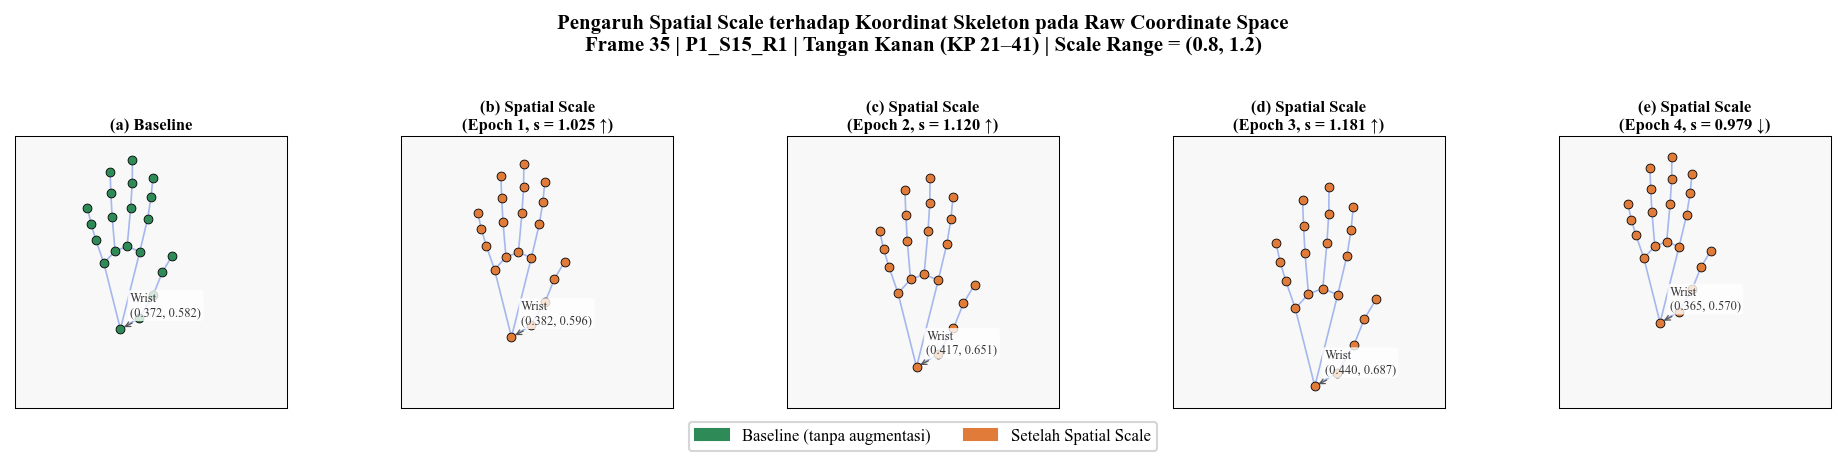

Saved: docs/perbandingan_baseline_vs_spatial_scale.png


In [9]:
COLOR_BASELINE = '#2E8B57'
COLOR_SCALE    = '#E07B39'

def _draw_hand(ax, pts, color):
    for p1, p2 in HAND_CONNS:
        if pts[p1, 0] == 0 or pts[p2, 0] == 0:
            continue
        ax.plot(
            [pts[p1, 0], pts[p2, 0]],
            [pts[p1, 1], pts[p2, 1]],
            color='#4169E1', alpha=0.45, lw=0.8, zorder=1
        )
    valid = pts[:, 0] != 0
    ax.scatter(
        pts[valid, 0], pts[valid, 1],
        c=color, s=18, edgecolors='black', linewidths=0.4, zorder=3
    )

# ── Shared bbox — square agar set_aspect('equal') tidak memotong
all_pts   = np.concatenate([orig_rh] + scaled_rh_list, axis=0)
valid_pts = all_pts[all_pts[:, 0] != 0]
pad       = 0.04
x_min, x_max = valid_pts[:, 0].min() - pad, valid_pts[:, 0].max() + pad
y_min, y_max = valid_pts[:, 1].min() - pad, valid_pts[:, 1].max() + pad
span  = max(x_max - x_min, y_max - y_min)
x_mid = (x_min + x_max) / 2
y_mid = (y_min + y_max) / 2
XLIM  = (x_mid - span / 2, x_mid + span / 2)
YLIM  = (y_mid - span / 2, y_mid + span / 2)

def plot_panel(ax, rh_21, title, color):
    _draw_hand(ax, rh_21, color)
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=8, pad=3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#F8F8F8')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

def annotate_wrist(ax, pts):
    wx, wy = pts[0]
    ax.annotate(
        f'Wrist\n({wx:.3f}, {wy:.3f})',
        xy=(wx, wy), xytext=(wx + 0.018, wy - 0.025),
        fontsize=6, color='#333333',
        arrowprops=dict(arrowstyle='->', color='#555', lw=0.6),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8)
    )

panel_size = 2.6
fig, axes  = plt.subplots(1, 5, figsize=(panel_size * 5, panel_size))

# Panel 0 — Baseline
plot_panel(axes[0], orig_rh, '(a) Baseline', COLOR_BASELINE)
annotate_wrist(axes[0], orig_rh)

# Panel 1–4 — Epoch
labels = ['(b)', '(c)', '(d)', '(e)']
for i, (rh_scaled, s) in enumerate(zip(scaled_rh_list, epoch_scales)):
    direction = '↓' if s < 1 else '↑'
    title = f'{labels[i]} Spatial Scale\n(Epoch {i+1}, s = {s:.3f} {direction})'
    plot_panel(axes[i + 1], rh_scaled, title, COLOR_SCALE)
    annotate_wrist(axes[i + 1], rh_scaled)

fig.legend(
    handles=[
        mpatches.Patch(color=COLOR_BASELINE, label='Baseline (tanpa augmentasi)'),
        mpatches.Patch(color=COLOR_SCALE,    label='Setelah Spatial Scale'),
    ],
    loc='lower center', ncol=2, fontsize=8,
    frameon=True, bbox_to_anchor=(0.5, -0.08)
)
fig.suptitle(
    'Pengaruh Spatial Scale terhadap Koordinat Skeleton pada Raw Coordinate Space\n'
    f'Frame {TARGET_FRAME} | {SELECTED_ID} | Tangan Kanan (KP 21–41) '
    f'| Scale Range = {scale_aug.scale_range}',
    fontsize=10, fontweight='bold', y=1.06
)

plt.tight_layout()
plt.savefig('docs/perbandingan_baseline_vs_spatial_scale.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved: docs/perbandingan_baseline_vs_spatial_scale.png')